In [106]:
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.preprocessing import scale,StandardScaler
from sklearn.model_selection import train_test_split,GridSearchCV,cross_val_predict
from sklearn.metrics import confusion_matrix,accuracy_score,mean_squared_error,r2_score,roc_auc_score,roc_curve,classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import warnings
warnings.simplefilter(action='ignore')
sns.set()
plt.style.use("ggplot")
%matplotlib inline

In [107]:
df=pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [108]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [109]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [110]:
# percentage of outcomes
# distribution of outcome
df["Outcome"].value_counts()*100/len(df)

Outcome
0    65.104167
1    34.895833
Name: count, dtype: float64

<Axes: xlabel='Age', ylabel='Count'>

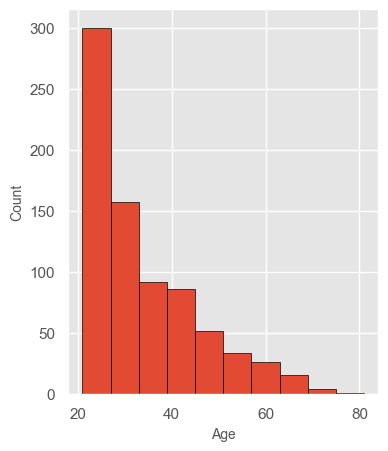

In [111]:
#plot hist of age
plt.figure(figsize=(4,5))
plt.xlabel('Age',fontsize=10)
plt.ylabel('Count',fontsize=10)
df['Age'].hist(edgecolor='black')

In [112]:
print("MAX AGE: "+str(df['Age'].max()) )
print("MIN AGE: "+str(df['Age'].min()))

MAX AGE: 81
MIN AGE: 21


In [113]:
#Density graph
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

<Axes: xlabel='Age', ylabel='Density'>

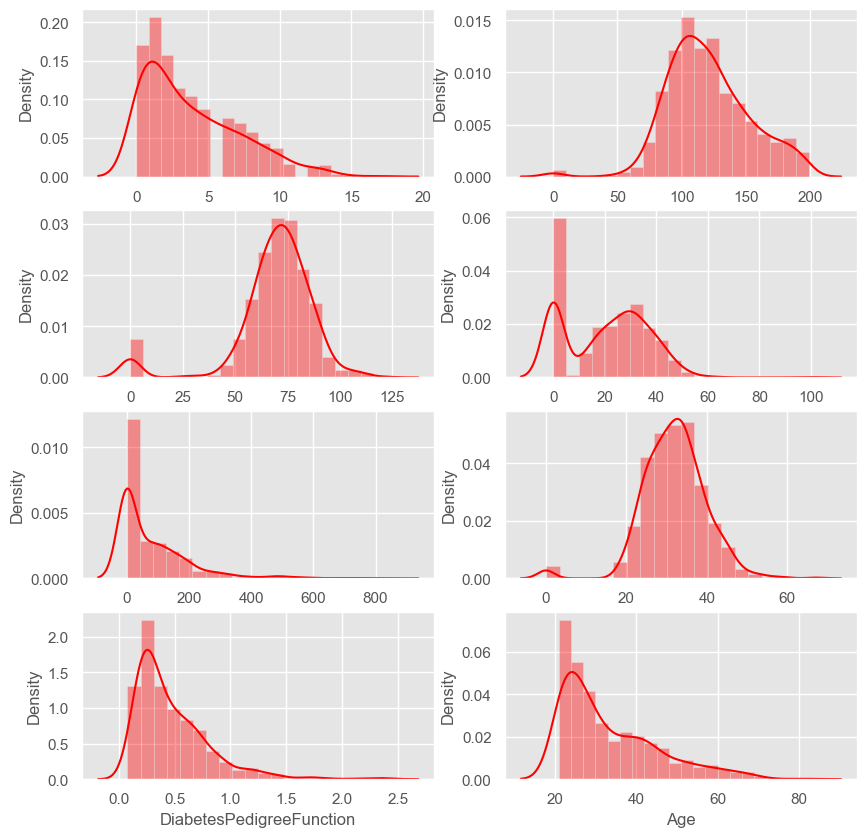

In [114]:
fig,ax=plt.subplots(4,2,figsize=(10,10))
sns.distplot(df.Pregnancies,bins=20,ax=ax[0,0],color="red")
sns.distplot(df.Glucose,bins=20,ax=ax[0,1],color="red")
sns.distplot(df.BloodPressure,bins=20,ax=ax[1,0],color="red")
sns.distplot(df.SkinThickness,bins=20,ax=ax[1,1],color="red")
sns.distplot(df.Insulin,bins=20,ax=ax[2,0],color="red")
sns.distplot(df.BMI,bins=20,ax=ax[2,1],color="red")
sns.distplot(df.DiabetesPedigreeFunction,bins=20,ax=ax[3,0],color="red")
sns.distplot(df.Age,bins=20,ax=ax[3,1],color="red")

In [115]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

In [116]:
cols = [
    "Pregnancies", "Glucose",
    "BloodPressure", "SkinThickness",
    "Insulin", "BMI",
    "DiabetesPedigreeFunction", "Age"
]

for i in range(0, len(cols), 2):
    print(df.groupby("Outcome").agg({
        cols[i]: ["mean", "min", "max"],
        cols[i+1]: ["mean", "min", "max"]
    }))
    print("-" * 60)

        Pregnancies             Glucose         
               mean min max        mean min  max
Outcome                                         
0          3.298000   0  13  109.980000   0  197
1          4.865672   0  17  141.257463   0  199
------------------------------------------------------------
        BloodPressure          SkinThickness        
                 mean min  max          mean min max
Outcome                                             
0           68.184000   0  122     19.664000   0  60
1           70.824627   0  114     22.164179   0  99
------------------------------------------------------------
            Insulin                 BMI           
               mean min  max       mean  min   max
Outcome                                           
0         68.792000   0  744  30.304200  0.0  57.3
1        100.335821   0  846  35.142537  0.0  67.1
------------------------------------------------------------
        DiabetesPedigreeFunction                    

In [117]:
df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


Text(0.5, 1.0, 'Correlation Matix')

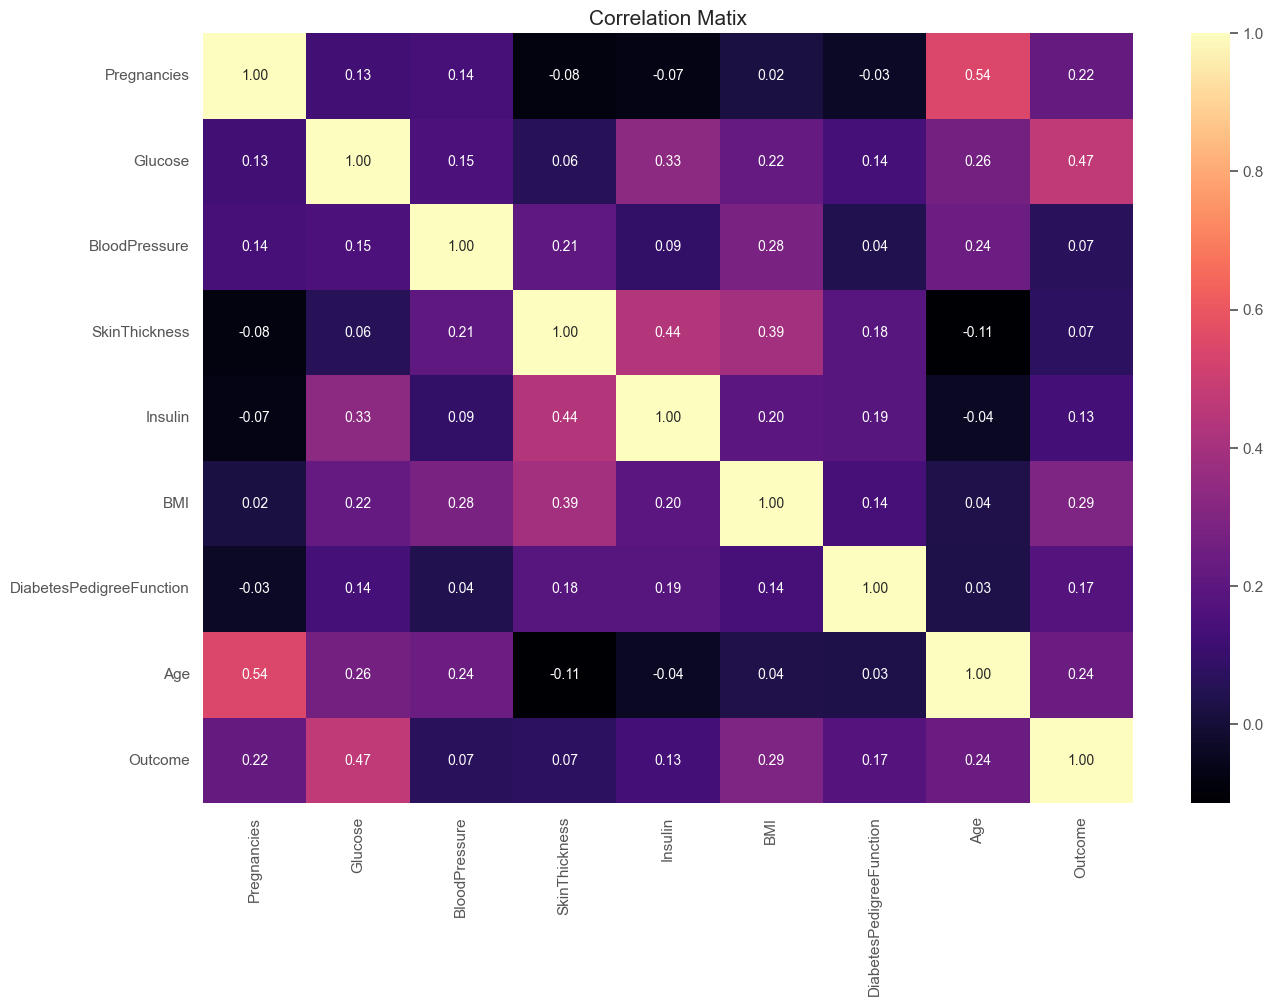

In [118]:
#EDA FINAL PART
f,ax=plt.subplots(figsize=[15,10])
sns.heatmap(df.corr(),annot=True,fmt='.2f',ax=ax,cmap='magma')
ax.set_title("Correlation Matix",fontsize=15)


In [119]:
#DATA PREPROCESSING
df = pd.read_csv("diabetes.csv")

In [120]:
#REPLACE 0 with NAN
cols = [
    'Pregnancies', 'Glucose', 'BloodPressure',
    'SkinThickness', 'Insulin', 'BMI',
    'DiabetesPedigreeFunction', 'Age'
]

df[cols] = df[cols].replace(0, np.nan)

In [121]:
df.isnull().sum()

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [122]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6.0,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1.0,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8.0,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,NaN,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [123]:
# Fill missing values with median based on Outcome

columns = df.columns.drop("Outcome")

for col in columns:
    median_0 = df[df["Outcome"] == 0][col].median()
    median_1 = df[df["Outcome"] == 1][col].median()

    df.loc[(df["Outcome"] == 0) & (df[col].isnull()), col] = median_0
    df.loc[(df["Outcome"] == 1) & (df[col].isnull()), col] = median_1

In [124]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6.0,148.0,72.0,35.0,169.5,33.6,0.627,50,1
1,1.0,85.0,66.0,29.0,102.5,26.6,0.351,31,0
2,8.0,183.0,64.0,32.0,169.5,23.3,0.672,32,1
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,5.0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


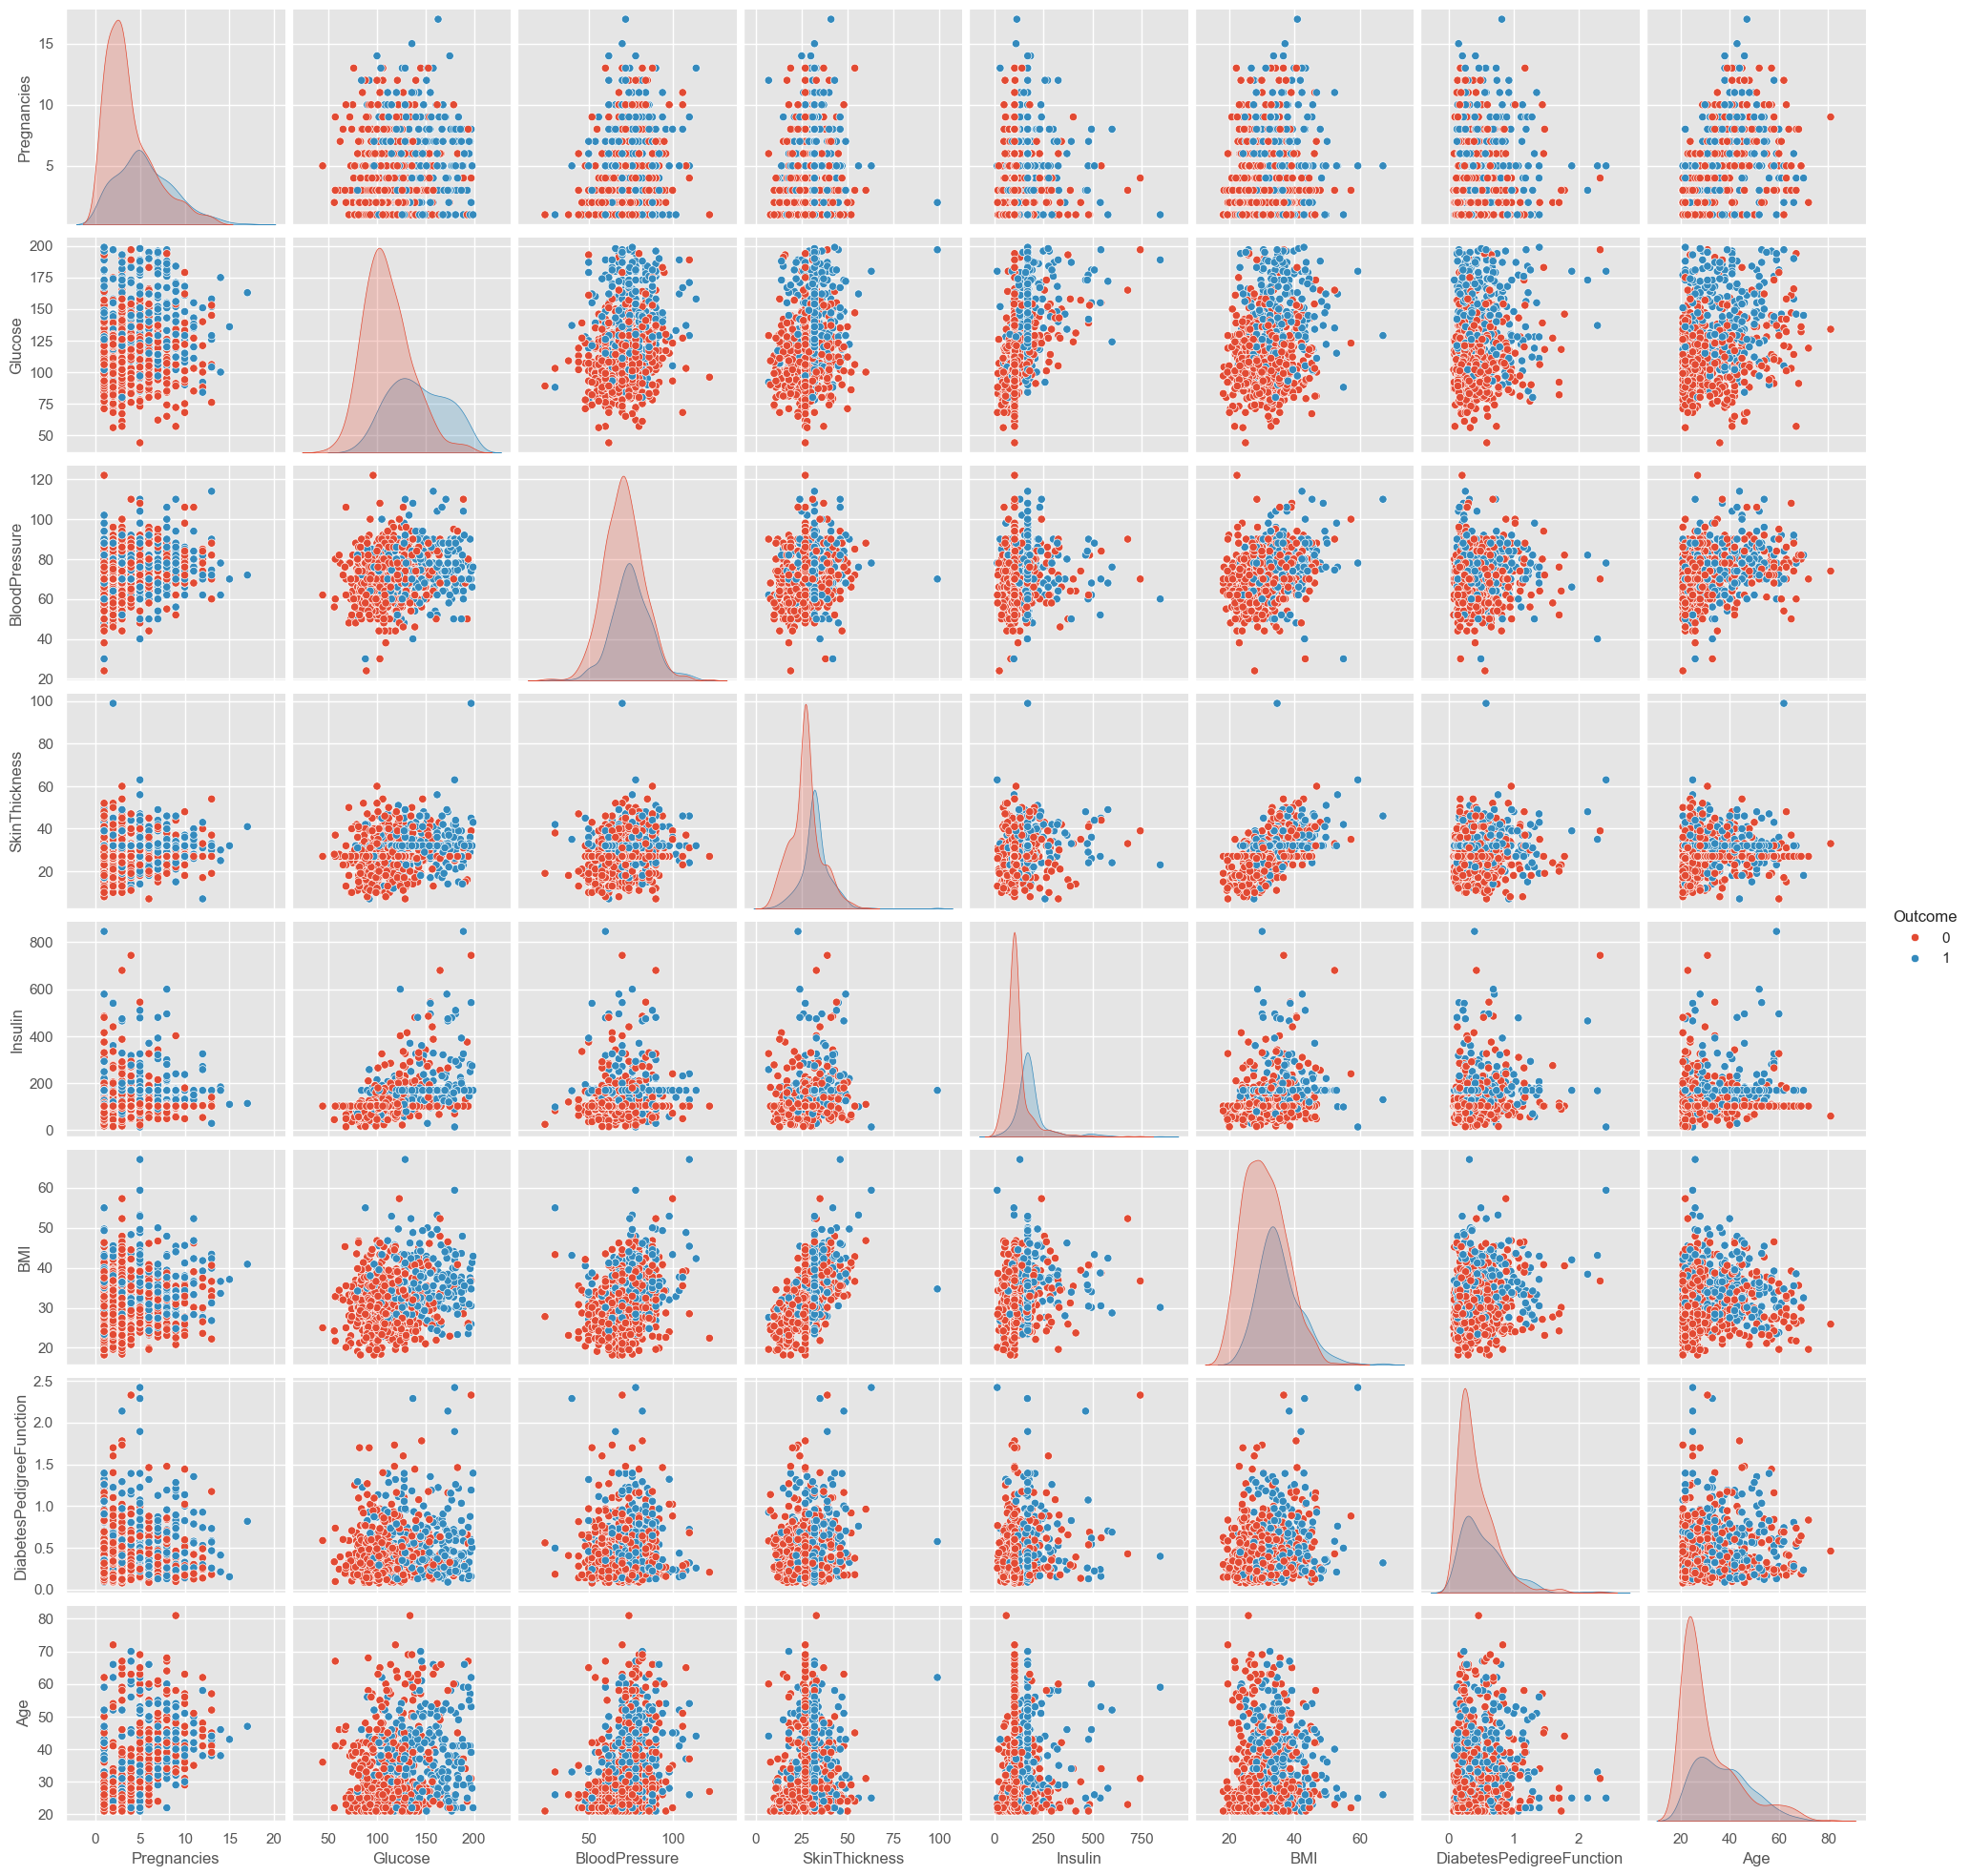

In [125]:
#PAIR PLOT
p=sns.pairplot(df,hue="Outcome")

In [126]:
# Count outliers using IQR

for col in df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - (1.5 * IQR)
    upper = Q3 + (1.5 * IQR)

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    print(col, ":", outliers)

Pregnancies : 14
Glucose : 0
BloodPressure : 14
SkinThickness : 87
Insulin : 51
BMI : 8
DiabetesPedigreeFunction : 29
Age : 9
Outcome : 0


In [127]:
#REMOVE OUTLIER
for col in df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

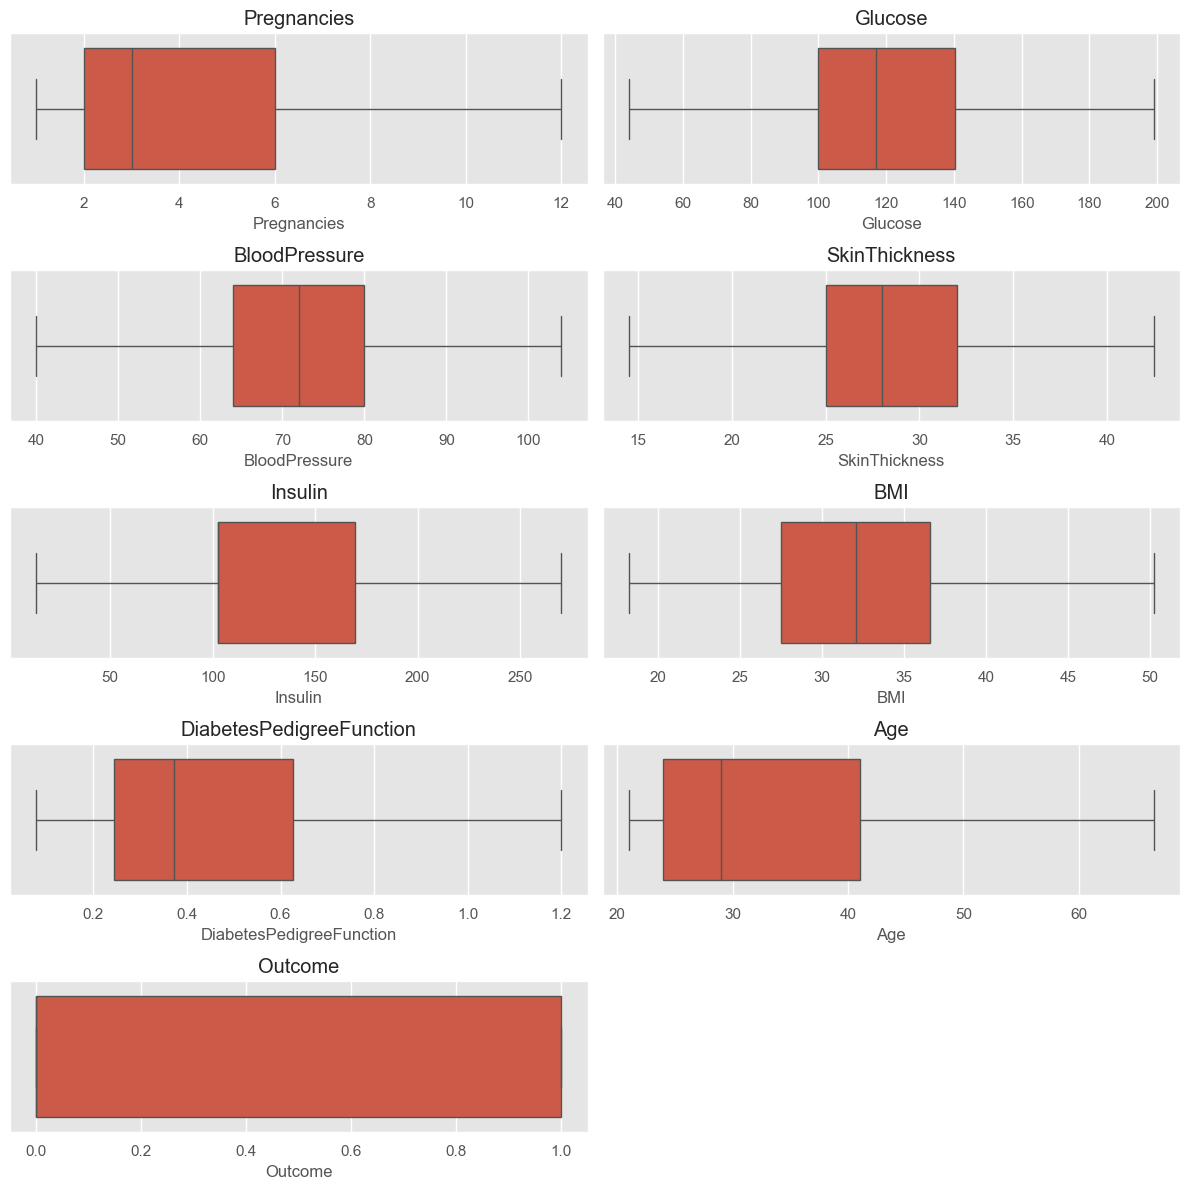

In [128]:


cols = df.columns

fig, axes = plt.subplots(nrows=(len(cols)+1)//2, ncols=2, figsize=(12, 12))

axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)


if len(cols) % 2 != 0:
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

In [129]:
#FEATURE ENG
bins = [0, 18.5, 25, 30, float("inf")]
labels = ["Underweight", "Normal", "Overweight", "Obese"]

df["NEW_BMI"] = pd.cut(df["BMI"], bins=bins, labels=labels)

In [130]:
bins = [0, 16, 166, float('inf')]
labels = ["Low", "Normal", "High"]

df["NEW_Insulin"] = pd.cut(df["Insulin"], bins=bins, labels=labels)

In [131]:
df.columns


Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome', 'NEW_BMI',
       'NEW_Insulin'],
      dtype='str')

In [132]:
df[df.filter(regex="^NEW").columns] = df.filter(regex="^NEW").astype(int)

ValueError: Cannot cast str dtype to int64

In [ ]:
cat_df = df.filter(regex="^NEW")
cat_df.head()

,NEW_BMI_Normal,NEW_BMI_Overweight,NEW_BMI_Obese,NEW_Insulin_Normal,NEW_Insulin_High
0,0,0,1,0,1
1,0,1,0,1,0
2,1,0,0,0,1
3,0,1,0,1,0
4,0,0,1,0,1


In [ ]:
X = df.drop(["Outcome",
             "NEW_BMI_Normal",
             "NEW_BMI_Overweight",
             "NEW_BMI_Obese",
             "NEW_Insulin_Normal",
             "NEW_Insulin_High"], axis=1)

y = df["Outcome"]

In [ ]:
cols=X.columns
index=X.index
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6.0,148.0,72.0,35.0,169.5,33.6,0.627,50.0
1,1.0,85.0,66.0,29.0,102.5,26.6,0.351,31.0
2,8.0,183.0,64.0,32.0,169.5,23.3,0.672,32.0
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0
4,5.0,137.0,40.0,35.0,168.0,43.1,1.200,33.0


In [ ]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

X_scaled.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.75,0.765432,0.000,1.000000,1.000000,0.170330,0.665359,1.235294
1,-0.50,-0.790123,-0.375,0.142857,0.000000,-0.598901,-0.056209,0.117647
2,1.25,1.629630,-0.500,0.571429,1.000000,-0.961538,0.783007,0.176471
3,-0.50,-0.691358,-0.375,-0.714286,-0.126866,-0.434066,-0.537255,-0.470588
4,0.50,0.493827,-2.000,1.000000,0.977612,1.214286,2.163399,0.235294


In [ ]:
X_final = pd.concat([X_scaled, cat_df], axis=1)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y,
    test_size=0.2,
    random_state=0,
    
)

In [ ]:
sclaer=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [ ]:
#ML ALGO
#LOGISTIC REG
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8961038961038961
[[98  9]
 [ 7 40]]
              precision    recall  f1-score   support

           0       0.93      0.92      0.92       107
           1       0.82      0.85      0.83        47

    accuracy                           0.90       154
   macro avg       0.87      0.88      0.88       154
weighted avg       0.90      0.90      0.90       154



In [ ]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           0       0.94      0.89      0.91       107
           1       0.77      0.87      0.82        47

    accuracy                           0.88       154
   macro avg       0.86      0.88      0.87       154
weighted avg       0.89      0.88      0.88       154

